## 6. Missing piece non linearity
 

### 6.1 Re-creating the non linear data

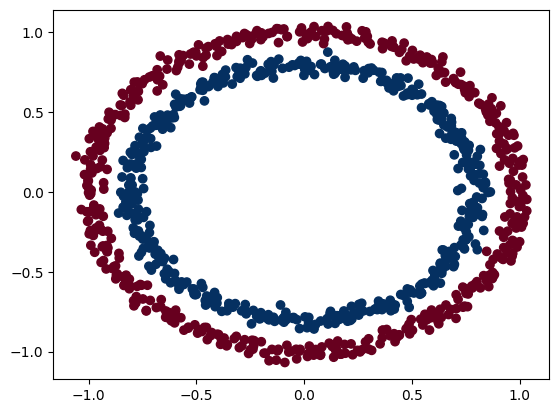

In [1]:
#Make and plot the data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
import numpy as np
n_samples = 1000 

X,y = make_circles(n_samples,noise = 0.03,random_state= 42)

plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdBu);


In [2]:
#Check data type and conevrt to tensors if it is not in tensor
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [3]:
#converting the data to tensors and then to train and test splits
import torch  
from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y= torch.from_numpy(y).type(torch.float)



#Split into train and test sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
X_train[:5] , y_test[:5]


(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 1., 0., 1.]))

## 6.2 Building a model with non linearity

In [4]:
#device agnostic code
import torch 
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
#Build a model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features = 2 , out_features = 10)
        self.layer2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer3 = nn.Linear(in_features =10 , out_features = 1)
        self.relu = nn.ReLU() #Relu is a non linear activation function
        self.sigmoid = nn.Sigmoid()
    def forward(self,x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

        #(input)layer 1 -> relu -> layer2 -> relu -> layer3(ouptut)



In [6]:
model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [7]:
#setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),lr = 0.1)


### 6.3 Training a model with non linearity

In [8]:
#Accuracy fucntion
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc 

In [13]:
#Random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train , y_train = X_train.to(device) , y_train.to(device)
X_test , y_test = X_test.to(device) , y_test.to(device)

#Loop through data
epochs = 1000
for epoch in  range(epochs):
    model_3.train()
    #1.Forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    #2calculate the loss
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true = y_train,y_pred = y_pred)
    #3.optimizer zero grad
    optimizer.zero_grad()
    #4.Loss backward
    loss.backward()
    #5.Step the optimizer 
    optimizer.step()
    #Testing
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true = y_test , y_pred = test_pred)

    if epoch % 100 == 0 :
        print(f"Epoch : {epoch}| Loss : {loss:.4f} | acc : {acc:.2f}% | Test loss : {test_loss:.4f} | Test accuracy :  {test_acc:.2f}%")

Epoch : 0| Loss : 0.0433 | acc : 100.00% | Test loss : 0.0712 | Test accuracy :  99.50%
Epoch : 100| Loss : 0.0347 | acc : 100.00% | Test loss : 0.0607 | Test accuracy :  100.00%
Epoch : 200| Loss : 0.0287 | acc : 100.00% | Test loss : 0.0531 | Test accuracy :  100.00%
Epoch : 300| Loss : 0.0244 | acc : 100.00% | Test loss : 0.0474 | Test accuracy :  100.00%
Epoch : 400| Loss : 0.0212 | acc : 100.00% | Test loss : 0.0428 | Test accuracy :  100.00%
Epoch : 500| Loss : 0.0186 | acc : 100.00% | Test loss : 0.0392 | Test accuracy :  100.00%
Epoch : 600| Loss : 0.0166 | acc : 100.00% | Test loss : 0.0361 | Test accuracy :  100.00%
Epoch : 700| Loss : 0.0150 | acc : 100.00% | Test loss : 0.0336 | Test accuracy :  100.00%
Epoch : 800| Loss : 0.0136 | acc : 100.00% | Test loss : 0.0315 | Test accuracy :  100.00%
Epoch : 900| Loss : 0.0124 | acc : 100.00% | Test loss : 0.0297 | Test accuracy :  100.00%


## 6.4 Evalvuating a model trained with non-linear activation fucntions

In [14]:
#make predictions
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

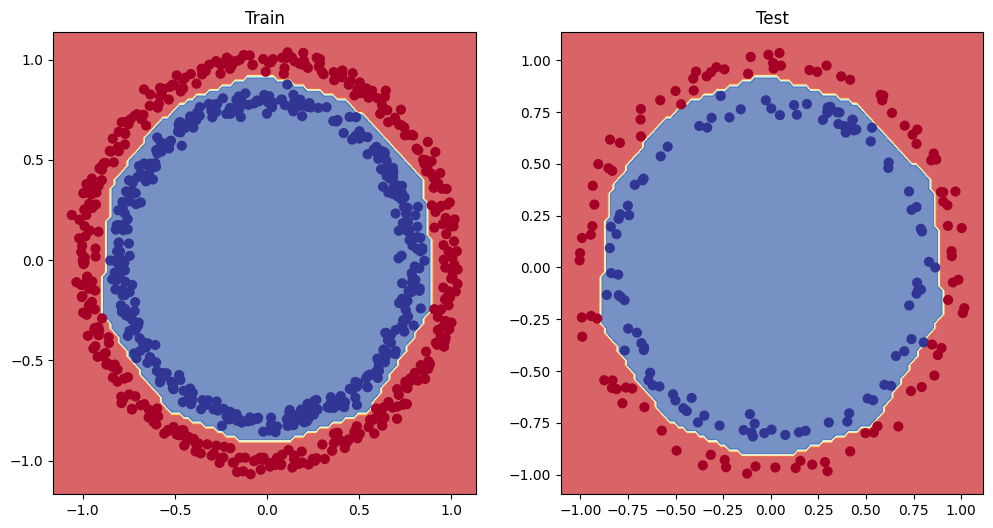

In [23]:
#plotting 

from helper_function import plot_decision_boundary,plot_predictions
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test)